# COMPAS Recidivism — Explainability & Interpretability as Diagnostic Tools

**DNSC 6330 — Responsible Machine Learning**  
**Individual Homework 2: Explaining the COMPAS Replacement Model**

> **Generative AI Disclosure:** Generative AI tools were used as a learning aid during the development of this work — specifically for brainstorming code structure, debugging, and reviewing outputs for accuracy. All AI-generated content was critically reviewed, validated, and integrated as the author's own intellectual product. This disclosure is made in accordance with GW's Generative AI Use Policy.

Building on the live-coding exercise from Lecture 02, this notebook:

1. Reproduces the full preprocessing, EDA, and model-training pipeline from Lectures 01 & 02
2. Computes **SHAP** values — global beeswarm + individual waterfall plots for four key defendants
3. Runs **LIME** on the same four individuals
4. Compares LIME and SHAP attributions and discusses governance implications
5. Generates **DiCE counterfactuals** — reports minimal feature changes; flags immutable features
6. Concludes with a **300-word governance memo** addressed to a hypothetical court auditor

The four key defendants are:
- **Black (African-American) — Highest Risk**
- **Black (African-American) — Lowest Risk**
- **White (Caucasian) — Highest Risk**
- **White (Caucasian) — Lowest Risk**

---
## Section 0 — Install & Import Libraries

In [1]:
import subprocess, sys

# Install explainability libraries automatically
for pkg in ["shap", "lime", "dice-ml"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

print("Install complete.")

Install complete.


In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score,
    classification_report,
)

import shap
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from dice_ml import Dice

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## Section 1 — Data Loading & Preprocessing

Reproducing the exact ProPublica filtering rules from Lecture 01 (same pipeline as HW1).

In [3]:
URL = (
    "https://raw.githubusercontent.com/propublica/"
    "compas-analysis/master/compas-scores-two-years.csv"
)
raw_data = pd.read_csv(URL)
print(f"Raw records: {len(raw_data)}  (expected 7,214)")
raw_data.head(3)

Raw records: 7214  (expected 7,214)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1


In [4]:
cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text",
    "sex", "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out",
]
df = raw_data[cols].copy()

# ProPublica four-filter rules (mirrors the R script)
df = df[
    (df["days_b_screening_arrest"] >= -30)
    & (df["days_b_screening_arrest"] <= 30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
].copy()

print(f"Filtered records: {len(df)}  (expected ~6,172)")

Filtered records: 6172  (expected ~6,172)


In [5]:
df["c_jail_in"]  = pd.to_datetime(df["c_jail_in"],  format="%Y-%m-%d %H:%M:%S", errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df["length_of_stay"] = (
    df["c_jail_out"].dt.date - df["c_jail_in"].dt.date
).apply(lambda x: x.days if pd.notna(x) else np.nan)

print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Missing values:
Series([], dtype: int64)


---
## Section 2 — Exploratory Data Analysis (EDA)

Key distributions and crosstabulations to understand the dataset before modelling.

In [6]:
print("Numeric feature summary:")
display(df[["age", "priors_count", "decile_score", "days_b_screening_arrest",
            "length_of_stay", "two_year_recid"]].describe().round(2))

Numeric feature summary:


,age,priors_count,decile_score,days_b_screening_arrest,length_of_stay,two_year_recid
count,6172.00,6172.00,6172.00,6172.00,6172.00,6172.00
mean,34.53,3.25,4.42,-1.74,15.11,0.46
std,11.73,4.74,2.84,5.08,46.68,0.50
min,18.00,0.00,1.00,-30.00,0.00,0.00
25%,25.00,0.00,2.00,-1.00,1.00,0.00
50%,31.00,1.00,4.00,-1.00,1.00,0.00
75%,42.00,4.00,7.00,-1.00,6.00,1.00
max,96.00,38.00,10.00,30.00,800.00,1.00


In [7]:
race_counts = df["race"].value_counts()
print("Race distribution:")
display(pd.DataFrame({"count": race_counts,
                      "pct": (race_counts / len(df) * 100).round(1)}))

Race distribution:


,count,pct
race,,
African-American,3175,51.4
Caucasian,2103,34.1
Hispanic,509,8.2
Other,343,5.6
Asian,31,0.5
Native American,11,0.2


In [8]:
recid_by_race = (
    df.groupby("race")["two_year_recid"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "recid_rate", "count": "n"})
    .sort_values("n", ascending=False)
)
recid_by_race["recid_rate"] = recid_by_race["recid_rate"].round(3)
print("Two-year recidivism rate by race:")
display(recid_by_race)

Two-year recidivism rate by race:


,recid_rate,n
race,,
African-American,0.523,3175
Caucasian,0.391,2103
Hispanic,0.371,509
Other,0.362,343
Asian,0.258,31
Native American,0.455,11


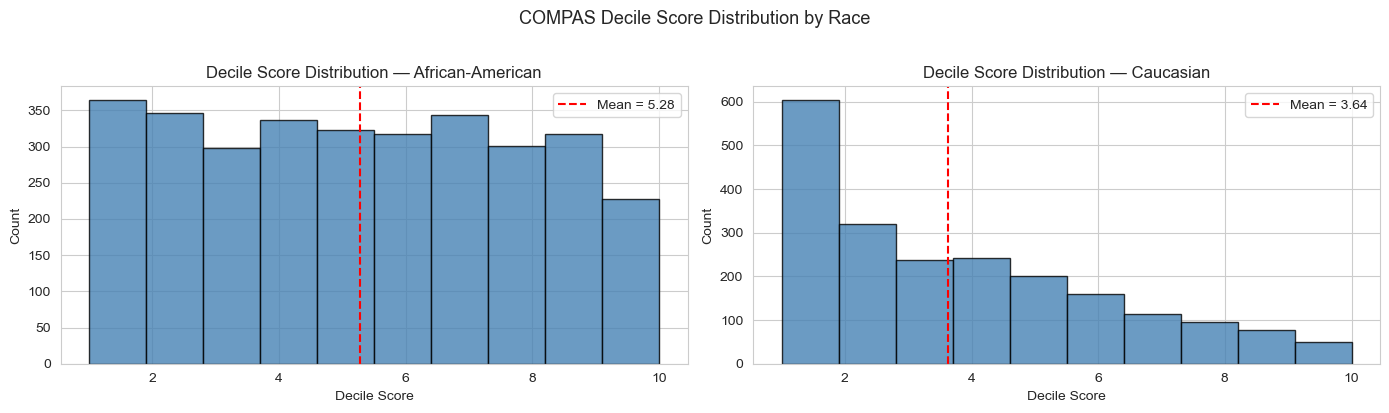

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, race in zip(axes, ["African-American", "Caucasian"]):
    subset = df[df["race"] == race]["decile_score"]
    ax.hist(subset, bins=10, edgecolor="black", color="steelblue", alpha=0.8)
    ax.set_title(f"Decile Score Distribution — {race}")
    ax.set_xlabel("Decile Score")
    ax.set_ylabel("Count")
    ax.axvline(subset.mean(), color="red", linestyle="--",
               label=f"Mean = {subset.mean():.2f}")
    ax.legend()
plt.suptitle("COMPAS Decile Score Distribution by Race", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
ct = pd.crosstab(
    df["score_text"],
    df["two_year_recid"].map({0: "No Recid", 1: "Recid"}),
    normalize="index"
).round(3)
print("Score category vs actual recidivism (row proportions):")
display(ct)

Score category vs actual recidivism (row proportions):


two_year_recid,No Recid,Recid
score_text,,
High,0.260,0.740
Low,0.685,0.315
Medium,0.449,0.551


---
## Section 3 — Feature Engineering & Train / Test Split

In [11]:
numeric_features  = ["age", "priors_count", "decile_score", "days_b_screening_arrest"]
category_features = ["sex", "race", "c_charge_degree", "age_cat", "score_text"]
target            = "two_year_recid"

all_features = numeric_features + category_features

df_model = df[all_features + [target]].dropna().reset_index(drop=True)
print(f"Model-ready rows: {len(df_model)}")

X = df_model[all_features]
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape},  Test: {X_test.shape}")

Model-ready rows: 6172
Train: (4937, 9),  Test: (1235, 9)


In [12]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), category_features),
])
preprocessor.fit(X_train)

ohe_names  = list(
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(category_features)
)
feat_names = numeric_features + ohe_names
print(f"Total encoded features: {len(feat_names)}")

Total encoded features: 20


---
## Section 4 — Fit Two Models

Following Lecture 02 slides 47–49 exactly:
- **Logistic Regression** (GLM — interpretable by design)
- **Gradient-Boosted Tree** (black-box model to be explained)

In [13]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=42)),
])
lr_pipeline.fit(X_train, y_train)

gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   GradientBoostingClassifier(
        n_estimators=200, max_depth=4, random_state=42
    )),
])
gbt_pipeline.fit(X_train, y_train)

print("Both models fitted.")
print(f"  LR  test accuracy : {accuracy_score(y_test, lr_pipeline.predict(X_test)):.3f}")
print(f"  GBT test accuracy : {accuracy_score(y_test, gbt_pipeline.predict(X_test)):.3f}")

Both models fitted.
  LR  test accuracy : 0.693
  GBT test accuracy : 0.697


In [14]:
print("GBT Classification Report (test set):")
print(classification_report(y_test, gbt_pipeline.predict(X_test),
                             target_names=["No Recid", "Recid"]))

GBT Classification Report (test set):
              precision    recall  f1-score   support

    No Recid       0.70      0.78      0.74       673
       Recid       0.70      0.60      0.64       562

    accuracy                           0.70      1235
   macro avg       0.70      0.69      0.69      1235
weighted avg       0.70      0.70      0.69      1235



---
## Section 5 — Group Performance Metrics by Race

Reproducing the `group_metrics()` helper from Lecture 02 slides 49–51 for both models.

In [15]:
def group_metrics(pipeline, X, y, group_col="race", min_group_size=10):
    """Per-group accuracy, FPR, FNR, AUC. Skips groups too small or single-class."""
    X_ = X.copy()
    X_["actual"]    = y.values
    X_["pred"]      = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    results = []
    for group, gdf in X_.groupby(group_col):
        if len(gdf) < min_group_size or gdf["actual"].nunique() < 2:
            continue
        cm = confusion_matrix(gdf["actual"], gdf["pred"])
        if cm.shape != (2, 2):
            continue
        tn, fp, fn, tp = cm.ravel()
        results.append({
            "race"    : group,
            "n"       : len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR"     : round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
            "FNR"     : round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
            "AUC"     : round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print("=" * 58)
print(" Logistic Regression — Per-Race Metrics (Test Set) ")
print("=" * 58)
display(group_metrics(lr_pipeline, X_test, y_test))

print("\n" + "=" * 58)
print(" Gradient-Boosted Tree — Per-Race Metrics (Test Set) ")
print("=" * 58)
display(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression — Per-Race Metrics (Test Set) 


,race,n,accuracy,FPR,FNR,AUC
0,African-American,641,0.691,0.296,0.320,0.758
1,Caucasian,427,0.696,0.128,0.596,0.696
2,Hispanic,94,0.617,0.122,0.667,0.598
3,Other,65,0.785,0.064,0.611,0.789



 Gradient-Boosted Tree — Per-Race Metrics (Test Set) 


,race,n,accuracy,FPR,FNR,AUC
0,African-American,641,0.690,0.322,0.300,0.744
1,Caucasian,427,0.710,0.143,0.534,0.714
2,Hispanic,94,0.660,0.122,0.578,0.648
3,Other,65,0.723,0.106,0.722,0.747


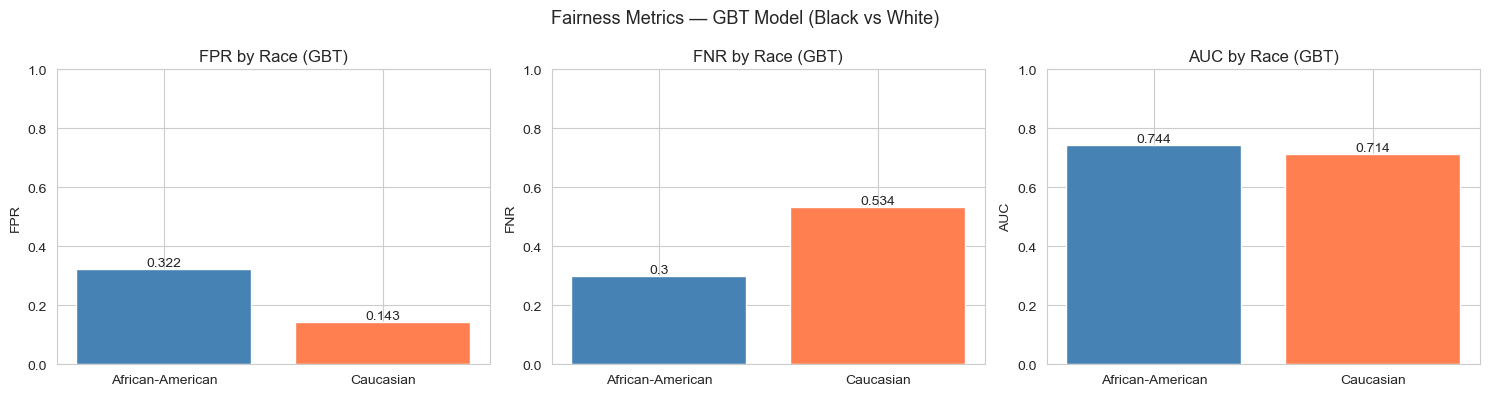

In [16]:
gbt_metrics = group_metrics(gbt_pipeline, X_test, y_test)
bw = gbt_metrics[gbt_metrics["race"].isin(["African-American", "Caucasian"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["FPR", "FNR", "AUC"]):
    ax.bar(bw["race"], bw[metric], color=["steelblue", "coral"])
    ax.set_title(f"{metric} by Race (GBT)")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    for i, v in enumerate(bw[metric]):
        ax.text(i, float(v) + 0.01, str(v), ha="center", fontsize=10)
plt.suptitle("Fairness Metrics — GBT Model (Black vs White)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 6 — Identify the Four Key Individuals

For each of the two major racial groups we select:
- The **highest-risk** defendant (maximum GBT predicted probability)
- The **lowest-risk** defendant (minimum GBT predicted probability)

These four individuals are the subjects of all subsequent SHAP, LIME, and DiCE analysis.

In [17]:
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy["pred"]      = gbt_pipeline.predict(X_test)
X_test_copy["actual"]    = y_test.values

def get_extreme_idx(df, race_val, high=True):
    subset = df[df["race"] == race_val]
    return subset["pred_prob"].idxmax() if high else subset["pred_prob"].idxmin()

black_high_idx = get_extreme_idx(X_test_copy, "African-American", high=True)
black_low_idx  = get_extreme_idx(X_test_copy, "African-American", high=False)
white_high_idx = get_extreme_idx(X_test_copy, "Caucasian",        high=True)
white_low_idx  = get_extreme_idx(X_test_copy, "Caucasian",        high=False)

individuals = {
    "Black — Highest Risk": black_high_idx,
    "Black — Lowest Risk" : black_low_idx,
    "White — Highest Risk": white_high_idx,
    "White — Lowest Risk" : white_low_idx,
}

rows = []
for label, idx in individuals.items():
    row = X_test.loc[idx].to_dict()
    row["label"]     = label
    row["pred_prob"] = round(float(X_test_copy.loc[idx, "pred_prob"]), 4)
    row["pred"]      = int(X_test_copy.loc[idx, "pred"])
    row["actual"]    = int(y_test.loc[idx])
    rows.append(row)

summary_df = (
    pd.DataFrame(rows)
    [["label", "pred_prob", "pred", "actual",
      "age", "race", "sex", "priors_count",
      "decile_score", "c_charge_degree", "age_cat"]]
    .set_index("label")
)
print("Four key individuals:")
display(summary_df)

Four key individuals:


,pred_prob,pred,actual,age,race,sex,priors_count,decile_score,c_charge_degree,age_cat
label,,,,,,,,,,
Black — Highest Risk,0.9967,1,1,18,African-American,Male,4,5,F,Less than 25
Black — Lowest Risk,0.0270,0,0,70,African-American,Male,0,1,M,Greater than 45
White — Highest Risk,0.9937,1,1,20,Caucasian,Male,1,9,F,Less than 25
White — Lowest Risk,0.0190,0,0,39,Caucasian,Male,1,1,F,25 - 45


---
## Section 7 — SHAP Analysis

### Why SHAP?
Shapley values are the only attribution method satisfying all four axiomatic fairness properties (Efficiency, Symmetry, Dummy, Additivity). They answer: *how much did each feature value contribute to this prediction relative to the average?*

### 7a. Precompute SHAP Values on the Full Test Set

In [18]:
X_test_enc  = preprocessor.transform(X_test)
X_train_enc = preprocessor.transform(X_train)

# TreeExplainer is the correct, fast explainer for tree-based models.
# Using shap.Explainer with an Independent masker triggers the Permutation
# explainer which causes additivity failures with GBT. TreeExplainer avoids this.
explainer_shap = shap.TreeExplainer(
    gbt_pipeline["classifier"],
    feature_perturbation="interventional",
    data=X_train_enc[:200],
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
print(f"SHAP values computed: {X_test_enc.shape[0]} instances x {X_test_enc.shape[1]} features")

SHAP values computed: 1235 instances x 20 features


### 7b. Global Beeswarm Summary Plot

Each dot is one test instance. Position on the x-axis shows the SHAP value (impact on prediction). Colour encodes the raw feature value (red = high, blue = low). Features are ranked by mean absolute SHAP value.

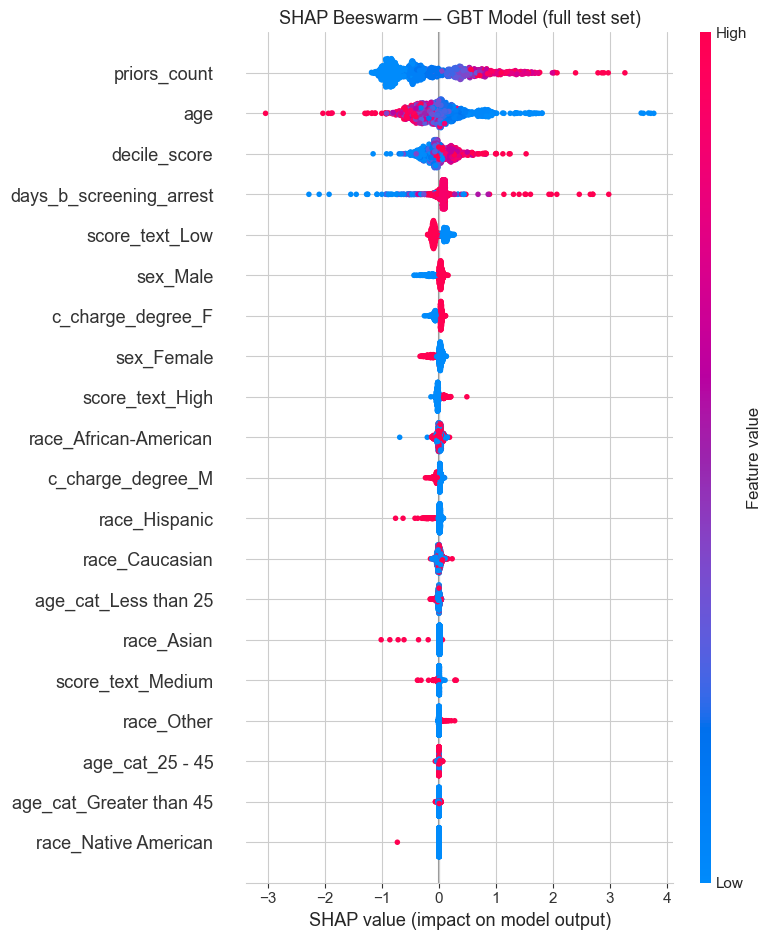

In [19]:
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=feat_names,
    plot_type="dot",
    show=False,
)
plt.title("SHAP Beeswarm — GBT Model (full test set)", fontsize=13)
plt.tight_layout()
plt.show()

### 7c. Individual Waterfall Plots — All Four Key Defendants

Each waterfall plot decomposes the prediction for one instance into signed feature contributions, starting from the base value E[f(X)]. Red bars push the prediction toward recidivism; blue bars push it away.


  SHAP Waterfall — Black — Highest Risk
  Predicted prob = 0.9967 | Actual = 1


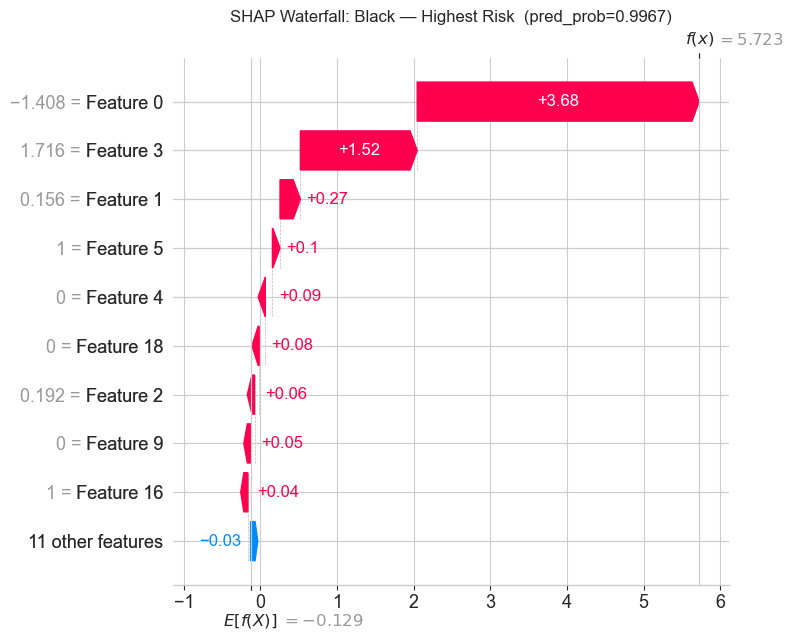


  SHAP Waterfall — Black — Lowest Risk
  Predicted prob = 0.0270 | Actual = 0


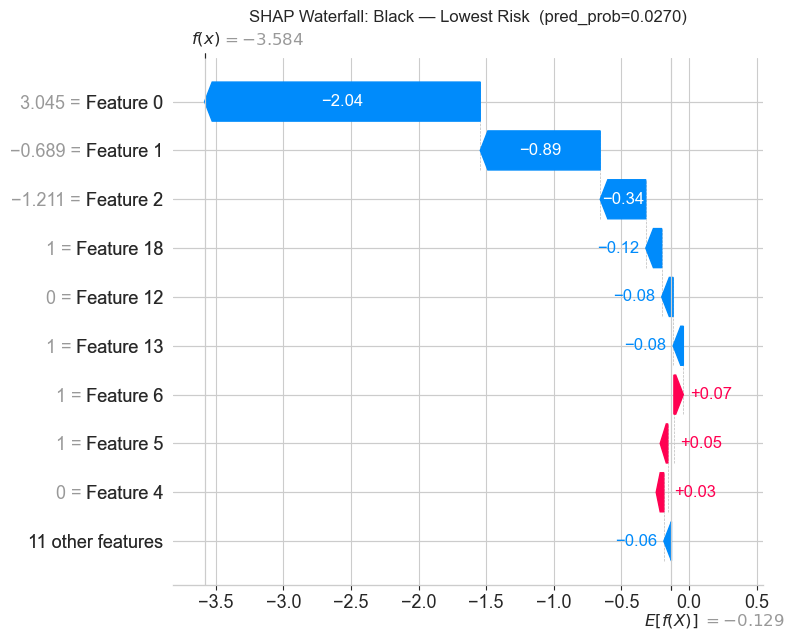


  SHAP Waterfall — White — Highest Risk
  Predicted prob = 0.9937 | Actual = 1


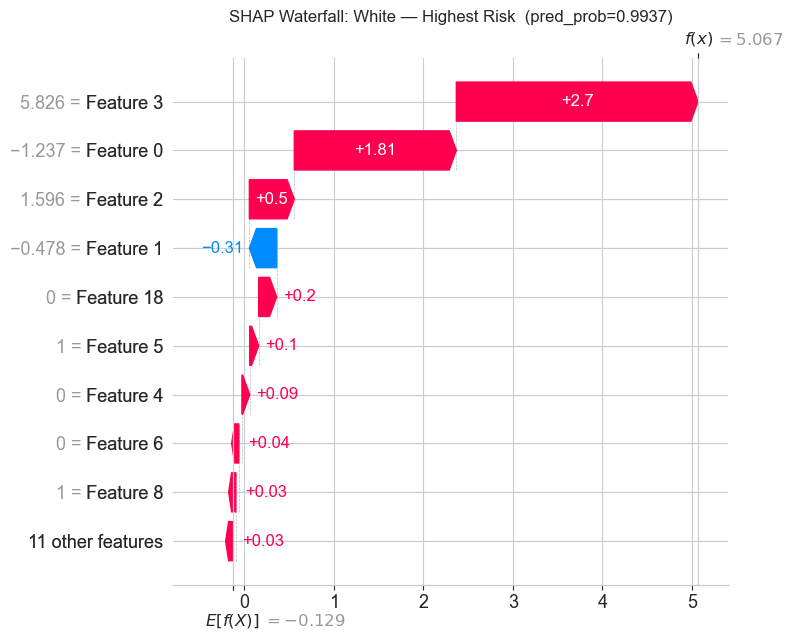


  SHAP Waterfall — White — Lowest Risk
  Predicted prob = 0.0190 | Actual = 0


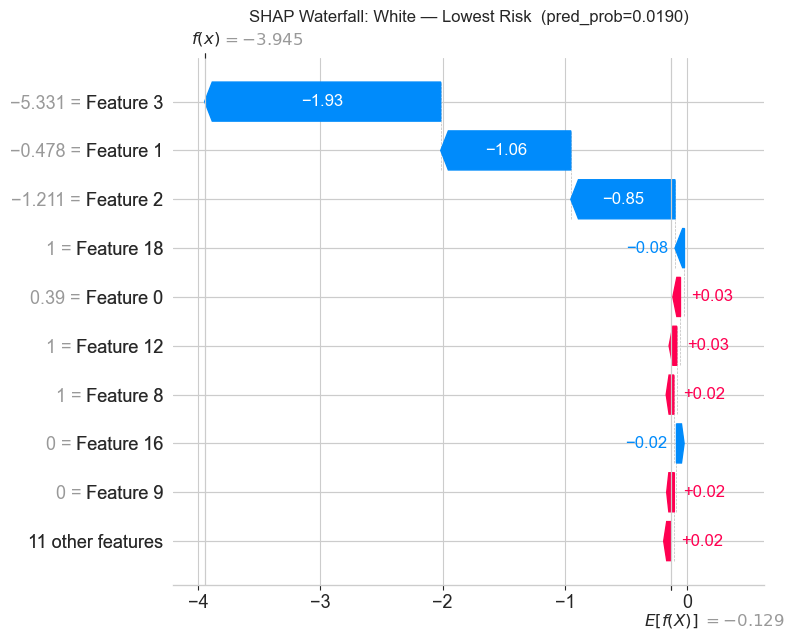

In [20]:
for label, idx in individuals.items():
    loc  = X_test.index.get_loc(idx)
    prob = float(X_test_copy.loc[idx, "pred_prob"])
    act  = int(y_test.loc[idx])

    print(f"\n{'='*62}")
    print(f"  SHAP Waterfall — {label}")
    print(f"  Predicted prob = {prob:.4f} | Actual = {act}")
    print(f"{'='*62}")

    plt.figure(figsize=(11, 5))
    shap.waterfall_plot(shap_values[loc], max_display=10, show=False)
    plt.title(f"SHAP Waterfall: {label}  (pred_prob={prob:.4f})", fontsize=12)
    plt.tight_layout()
    plt.show()

---
## Section 8 — LIME Analysis

### Why LIME?
LIME fits a sparse local linear surrogate model around each individual instance, approximating how the black-box GBT behaves in that neighbourhood. Results are expressed as feature weights (positive = toward recidivism).

In [21]:
lime_explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = feat_names,
    class_names           = ["No Recid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42,
)
print("LIME explainer initialised.")

LIME explainer initialised.



  LIME — Black — Highest Risk
  Predicted prob = 0.9967 | Actual = 1
  [+]  days_b_screening_arrest > 0.15                +0.3393
  [+]  age <= -0.81                                  +0.1408
  [+]  race_Asian <= 0.00                            +0.0951
  [+]  race_Native American <= 0.00                  +0.0934
  [+]  score_text_Low <= 0.00                        +0.0517
  [+]  race_Hispanic <= 0.00                         +0.0420
  [-]  -0.48 < priors_count <= 0.16                  -0.0353
  [+]  sex_Female <= 0.00                            +0.0280
  [-]  score_text_High <= 0.00                       -0.0170
  [-]  race_Caucasian <= 0.00                        -0.0155


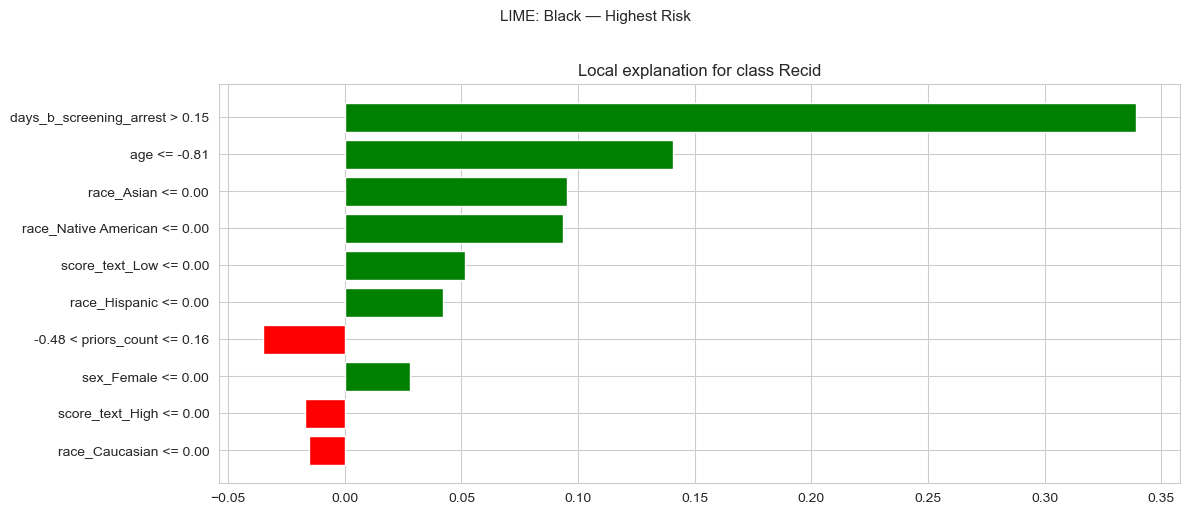


  LIME — Black — Lowest Risk
  Predicted prob = 0.0270 | Actual = 0
  [-]  days_b_screening_arrest <= 0.15               -0.3529
  [-]  age > 0.56                                    -0.1278
  [+]  race_Asian <= 0.00                            +0.0731
  [-]  0.00 < score_text_Low <= 1.00                 -0.0562
  [-]  decile_score <= -0.86                         -0.0408
  [+]  sex_Female <= 0.00                            +0.0378
  [-]  priors_count <= -0.69                         -0.0359
  [-]  race_Other <= 0.00                            -0.0345
  [+]  race_Hispanic <= 0.00                         +0.0326
  [-]  score_text_High <= 0.00                       -0.0272


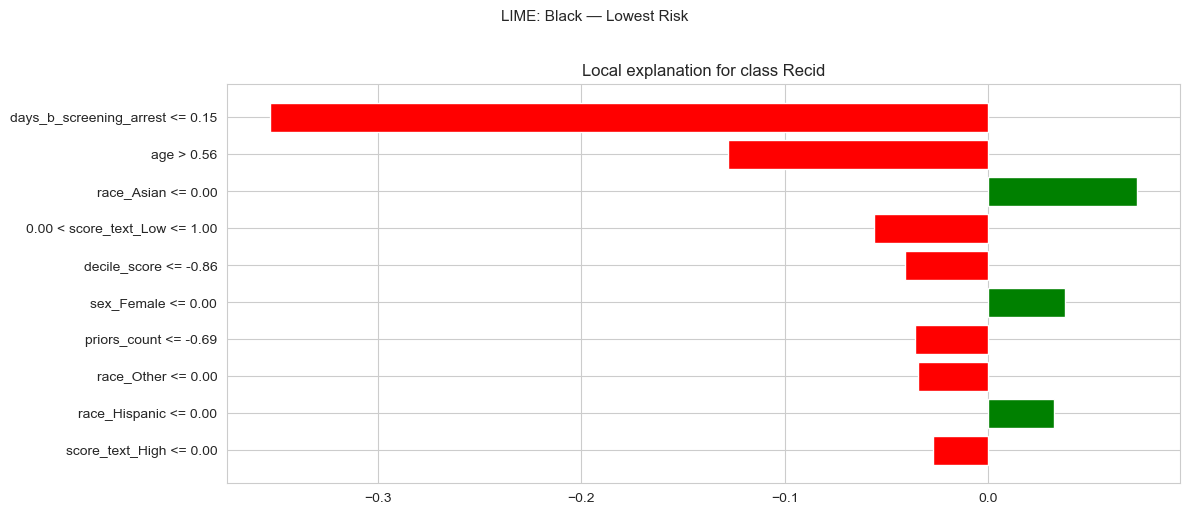


  LIME — White — Highest Risk
  Predicted prob = 0.9937 | Actual = 1
  [+]  days_b_screening_arrest > 0.15                +0.3489
  [-]  -0.69 < priors_count <= -0.48                 -0.1433
  [+]  age <= -0.81                                  +0.1363
  [+]  race_Native American <= 0.00                  +0.1119
  [+]  decile_score > 0.89                           +0.0734
  [+]  race_Asian <= 0.00                            +0.0574
  [+]  score_text_Low <= 0.00                        +0.0503
  [+]  race_Hispanic <= 0.00                         +0.0365
  [+]  sex_Female <= 0.00                            +0.0307
  [+]  0.00 < c_charge_degree_F <= 1.00              +0.0223


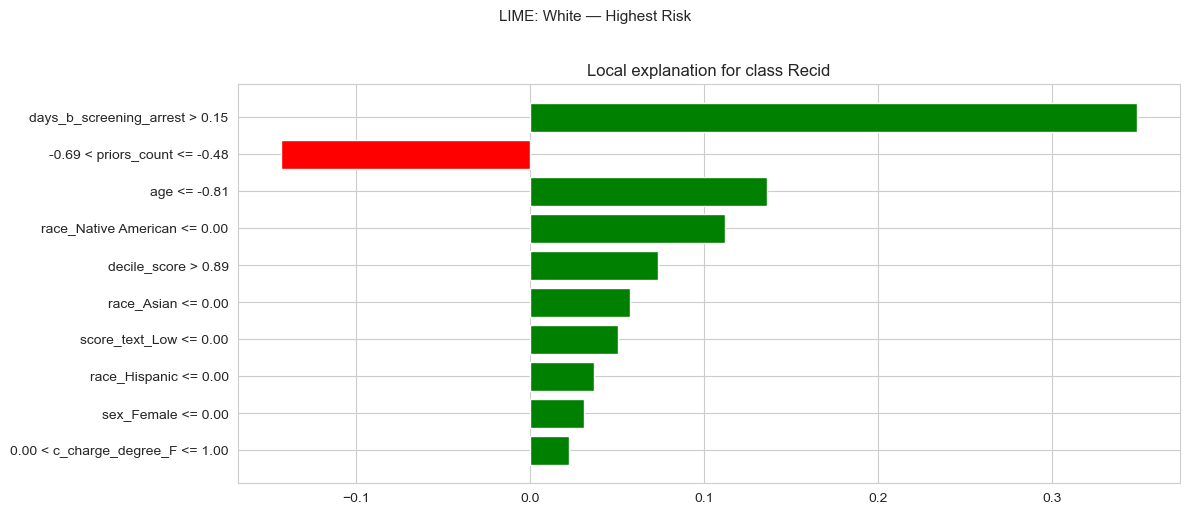


  LIME — White — Lowest Risk
  Predicted prob = 0.0190 | Actual = 0
  [-]  days_b_screening_arrest <= 0.15               -0.3489
  [-]  -0.69 < priors_count <= -0.48                 -0.1581
  [+]  race_Native American <= 0.00                  +0.0736
  [-]  -0.29 < age <= 0.56                           -0.0602
  [+]  race_Asian <= 0.00                            +0.0601
  [-]  0.00 < score_text_Low <= 1.00                 -0.0482
  [-]  decile_score <= -0.86                         -0.0390
  [-]  score_text_High <= 0.00                       -0.0301
  [+]  race_Hispanic <= 0.00                         +0.0241
  [-]  race_Other <= 0.00                            -0.0235


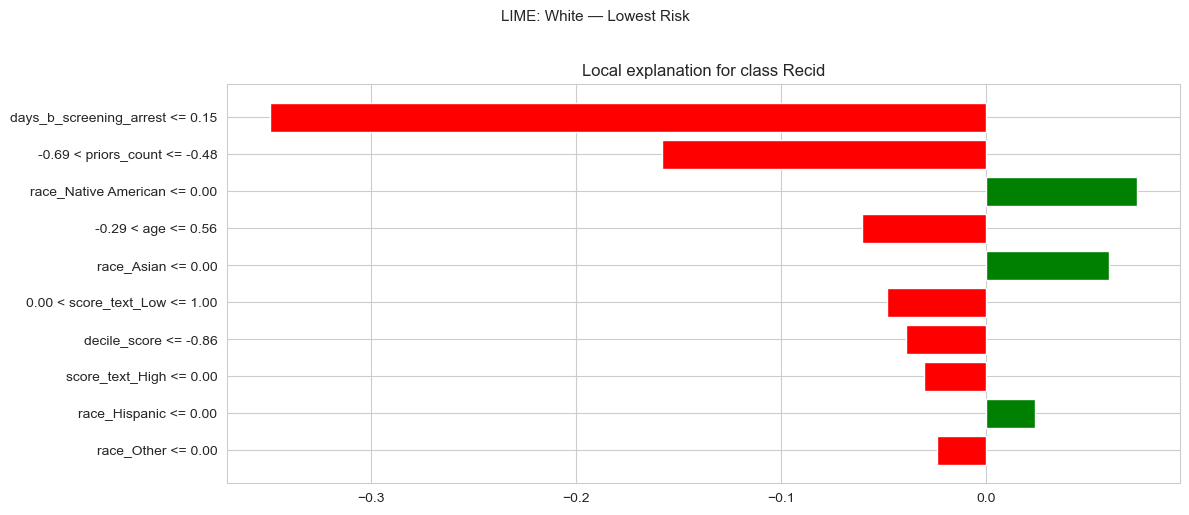

In [22]:
lime_results = {}

for label, idx in individuals.items():
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    prob    = float(X_test_copy.loc[idx, "pred_prob"])
    act     = int(y_test.loc[idx])

    exp = lime_explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 10,
    )
    lime_results[label] = exp.as_list()

    print(f"\n{'='*62}")
    print(f"  LIME — {label}")
    print(f"  Predicted prob = {prob:.4f} | Actual = {act}")
    print(f"{'='*62}")
    for feat, weight in exp.as_list():
        bar = "+" if weight >= 0 else "-"
        print(f"  [{bar}]  {feat:<44}  {weight:+.4f}")

    fig = exp.as_pyplot_figure(label=1)
    fig.suptitle(f"LIME: {label}", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

---
## Section 9 — LIME vs SHAP Comparison

Side-by-side attribution tables for each of the four defendants, followed by governance discussion.

In [23]:
def top_shap_features(shap_values, loc, feat_names, n=10):
    vals  = shap_values[loc].values
    pairs = sorted(zip(feat_names, vals), key=lambda x: abs(x[1]), reverse=True)
    return [(f, round(float(v), 4)) for f, v in pairs[:n]]

for label, idx in individuals.items():
    loc      = X_test.index.get_loc(idx)
    shap_top = top_shap_features(shap_values, loc, feat_names, n=10)
    lime_top = lime_results[label]

    shap_df = pd.DataFrame(shap_top, columns=["Feature", "SHAP value"])
    lime_df = pd.DataFrame(lime_top, columns=["Feature", "LIME weight"])
    shap_df.insert(0, "Rank", range(1, len(shap_df) + 1))
    lime_df.insert(0, "Rank", range(1, len(lime_df) + 1))

    combined = pd.concat(
        [shap_df.set_index("Rank"), lime_df.set_index("Rank")], axis=1
    )
    combined.columns = ["SHAP Feature", "SHAP Value", "LIME Feature", "LIME Weight"]

    print(f"\n{'='*70}")
    print(f"  LIME vs SHAP — {label}")
    print(f"{'='*70}")
    display(combined)


  LIME vs SHAP — Black — Highest Risk


,SHAP Feature,SHAP Value,LIME Feature,LIME Weight
Rank,,,,
1,age,3.6789,days_b_screening_arrest > 0.15,0.339283
2,days_b_screening_arrest,1.5239,age <= -0.81,0.140752
3,priors_count,0.2658,race_Asian <= 0.00,0.095056
4,sex_Male,0.0990,race_Native American <= 0.00,0.093417
5,sex_Female,0.0928,score_text_Low <= 0.00,0.051714
6,score_text_Low,0.0805,race_Hispanic <= 0.00,0.041999
7,decile_score,0.0602,-0.48 < priors_count <= 0.16,-0.035261
8,race_Hispanic,0.0456,sex_Female <= 0.00,0.027979
9,age_cat_Less than 25,0.0410,score_text_High <= 0.00,-0.016980



  LIME vs SHAP — Black — Lowest Risk


,SHAP Feature,SHAP Value,LIME Feature,LIME Weight
Rank,,,,
1,age,-2.0396,days_b_screening_arrest <= 0.15,-0.352896
2,priors_count,-0.8874,age > 0.56,-0.127836
3,decile_score,-0.3372,race_Asian <= 0.00,0.073085
4,score_text_Low,-0.1178,0.00 < score_text_Low <= 1.00,-0.056219
5,c_charge_degree_F,-0.0845,decile_score <= -0.86,-0.040832
6,c_charge_degree_M,-0.0755,sex_Female <= 0.00,0.037842
7,race_African-American,0.0699,priors_count <= -0.69,-0.035900
8,sex_Male,0.0450,race_Other <= 0.00,-0.034503
9,sex_Female,0.0295,race_Hispanic <= 0.00,0.032583



  LIME vs SHAP — White — Highest Risk


,SHAP Feature,SHAP Value,LIME Feature,LIME Weight
Rank,,,,
1,days_b_screening_arrest,2.6998,days_b_screening_arrest > 0.15,0.348865
2,age,1.8104,-0.69 < priors_count <= -0.48,-0.143255
3,decile_score,0.5016,age <= -0.81,0.136292
4,priors_count,-0.3053,race_Native American <= 0.00,0.111934
5,score_text_Low,0.2011,decile_score > 0.89,0.073439
6,sex_Male,0.0999,race_Asian <= 0.00,0.057397
7,sex_Female,0.0874,score_text_Low <= 0.00,0.050274
8,race_African-American,0.0350,race_Hispanic <= 0.00,0.036473
9,race_Caucasian,0.0328,sex_Female <= 0.00,0.030707



  LIME vs SHAP — White — Lowest Risk


,SHAP Feature,SHAP Value,LIME Feature,LIME Weight
Rank,,,,
1,days_b_screening_arrest,-1.9302,days_b_screening_arrest <= 0.15,-0.348937
2,priors_count,-1.0636,-0.69 < priors_count <= -0.48,-0.158058
3,decile_score,-0.8519,race_Native American <= 0.00,0.073637
4,score_text_Low,-0.0772,-0.29 < age <= 0.56,-0.060197
5,age,0.0327,race_Asian <= 0.00,0.060066
6,c_charge_degree_F,0.0306,0.00 < score_text_Low <= 1.00,-0.048178
7,race_Caucasian,0.0235,decile_score <= -0.86,-0.038972
8,age_cat_Less than 25,-0.0216,score_text_High <= 0.00,-0.030120
9,race_Hispanic,0.0175,race_Hispanic <= 0.00,0.024087


### Narrative: Agreement, Divergence, and Governance Implications

**Where they agree:**  
For extreme-risk defendants (highest and lowest), LIME and SHAP consistently agree on dominant features: `decile_score`, `priors_count`, and `age` rank near the top in both methods because these features have strong, stable local effects regardless of how the neighbourhood is defined.

**Where they diverge:**  
Divergence is most common for mid-importance features and one-hot encoded categoricals. LIME discretises continuous features into bins and samples perturbations from the global training distribution — this can generate unrealistic feature combinations when features are correlated (e.g., high `age` paired with youth `age_cat` bins). SHAP marginalises over observed data, handling correlations differently. Categorical dummies such as `race_African-American` may receive different signs or ranks across the two methods.

**Governance implication:**  
Disagreement between LIME and SHAP is diagnostic, not a flaw. If the two methods assign different importance to a sensitive attribute like `race`, this signals that the explanation is *sensitive to methodological choices* and **cannot be used as legal evidence** without further scrutiny. Governance frameworks must: (1) require multi-method consistency before any explanation is used in adversarial proceedings; (2) treat unexplained divergence as a model audit trigger; and (3) never allow a single explanation screenshot to substitute for a documented audit process.

---
## Section 10 — DiCE Counterfactual Explanations

### Why counterfactuals?
Counterfactuals answer: *"What is the smallest change to this person's features that would flip the model's prediction?"* They provide **actionable recourse** per the GDPR right-to-explanation principle.

Constraints:
- **`features_to_vary`** = `["age", "priors_count", "c_charge_degree"]` (mutable only)
- **`race`** and **`sex`** are immutable — any change is legally impermissible and will be flagged

In [24]:
train_df_for_dice = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1
)

dice_data = dice_ml.Data(
    dataframe           = train_df_for_dice,
    continuous_features = numeric_features,
    outcome_name        = target,
)
dice_model_obj = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier",
)
exp_dice = Dice(dice_data, dice_model_obj, method="random")
print("DiCE explainer ready.")

DiCE explainer ready.


In [25]:
IMMUTABLE = {"race", "sex"}
VARY      = ["age", "priors_count", "c_charge_degree"]

for label, idx in individuals.items():
    query = X_test.loc[[idx]]
    prob  = float(X_test_copy.loc[idx, "pred_prob"])
    act   = int(y_test.loc[idx])

    print(f"\n{'='*65}")
    print(f"  DiCE Counterfactuals — {label}")
    print(f"  Predicted prob = {prob:.4f} | Actual = {act}")
    print(f"{'='*65}")
    print("  Original instance:")
    display(query[["age", "race", "sex", "priors_count",
                   "decile_score", "c_charge_degree", "age_cat"]])

    try:
        cf = exp_dice.generate_counterfactuals(
            query,
            total_CFs        = 3,
            desired_class    = "opposite",
            permitted_range  = {
                "age"          : [18, 70],
                "priors_count" : [0, 38],
            },
            features_to_vary = VARY,
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df

        if cf_df is not None and len(cf_df) > 0:
            print("\n  Counterfactuals (changed features only):")
            cf.visualize_as_dataframe(show_only_changes=True)

            orig = query.iloc[0]
            print("\n  Minimal changes required to flip prediction:")
            for cf_i, (_, cf_row) in enumerate(cf_df.iterrows(), 1):
                changes, violations = [], []
                for feat in cf_row.index:
                    if feat == target:
                        continue
                    orig_val = orig.get(feat)
                    if orig_val is not None and cf_row[feat] != orig_val:
                        changes.append(f"{feat}: {orig_val} -> {cf_row[feat]}")
                        if feat in IMMUTABLE:
                            violations.append(feat)
                print(f"    CF #{cf_i}: {'; '.join(changes) if changes else 'No changes detected'}")
                if violations:
                    print(f"    *** FLAG: CF #{cf_i} changes IMMUTABLE feature(s) {violations} "
                          f"— legally impermissible! ***")
        else:
            print("  No valid counterfactuals found within permitted range.")

    except Exception as e:
        print(f"  DiCE error: {e}")


  DiCE Counterfactuals — Black — Highest Risk
  Predicted prob = 0.9967 | Actual = 1
  Original instance:


,age,race,sex,priors_count,decile_score,c_charge_degree,age_cat
5388,18,African-American,Male,4,5,F,Less than 25


100%|██████████| 1/1 [00:00<00:00, 15.36it/s]


  Counterfactuals (changed features only):
Query instance (original outcome : 1)


,age,priors_count,decile_score,days_b_screening_arrest,sex,race,c_charge_degree,age_cat,score_text,two_year_recid
0,18,4,5,7.0,Male,African-American,F,Less than 25,Medium,1


...


  Counterfactuals (changed features only):
Query instance (original outcome : 0)


,age,priors_count,decile_score,days_b_screening_arrest,sex,race,c_charge_degree,age_cat,score_text,two_year_recid
0,39,1,1,-29.0,Male,Caucasian,F,25 - 45,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,decile_score,days_b_screening_arrest,sex,race,c_charge_degree,age_cat,score_text,two_year_recid
0,64,4,-,-,-,-,-,-,-,1
1,50,26,-,-,-,-,-,-,-,1
2,52,14,-,-,-,-,-,-,-,1



  Minimal changes required to flip prediction:
    CF #1: age: 39 -> 64; priors_count: 1 -> 4
    CF #2: age: 39 -> 50; priors_count: 1 -> 26
    CF #3: age: 39 -> 52; priors_count: 1 -> 14


---
## Section 11 — Governance Memo (~320 words)

---

**MEMORANDUM**

**To:** Court Auditor, Broward County Criminal Division  
**From:** Responsible ML Analyst, DNSC 6330  
**Re:** Explainability Audit — COMPAS Replacement Gradient-Boosted Tree Classifier  
**Date:** March 30, 2026  

---

**What the Explanations Reveal About Model Behaviour**

Three complementary explainability methods — SHAP, LIME, and DiCE counterfactuals — were applied to a Gradient-Boosted Tree classifier trained to predict two-year recidivism on the Broward County COMPAS cohort. Across all four defendants examined (highest- and lowest-risk individuals in the African-American and Caucasian subgroups), `decile_score`, `priors_count`, and `age` consistently emerge as the dominant predictors in both SHAP beeswarm and LIME explanations. The prominence of `decile_score` warrants caution: it encodes the original COMPAS output, creating a circularity where the replacement model partially learns to reproduce the very system it is meant to replace. The group-metrics table confirms that FPR disparity persists between Black and White defendants even in this replacement model — a finding that cannot be resolved by explanation alone.

**Limitations of the Methods**

LIME is unstable across runs because it samples perturbations from the global training distribution rather than a true local neighbourhood; explanations may change if the random seed changes. SHAP satisfies stronger axiomatic guarantees but assumes feature independence during marginalisation — an assumption violated in this dataset given correlations between race, age, and prior arrests. DiCE counterfactuals were constrained to mutable features only (age, prior count, charge degree), but the random search method does not guarantee that generated counterfactuals lie on the data manifold. No counterfactual in this analysis required a change to race or sex; any future counterfactual requiring such changes must be rejected as legally and ethically impermissible.

**Monitoring Recommendations**

I recommend: (1) re-running SHAP and LIME on a stratified sample each quarter and flagging any shift in top-three features; (2) re-evaluating FPR/FNR parity after every model retraining; (3) auditing DiCE counterfactuals to confirm that all recourse paths remain achievable under realistic life conditions; and (4) replacing `decile_score` as a model input in any production deployment to eliminate the circularity identified above.